# Part 2: Hebb's Rule (1949) and Oja's Rule

## 1. Import Libraries
Import necessary libraries like NumPy for numerical operations and Matplotlib for data visualization.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

## 2. Generate Clustered Data for Learning
Create a synthetic 2D dataset with distinct clusters. This data will be used to train the Hebbian and Oja learning rules. Visualize the generated data using a scatter plot.

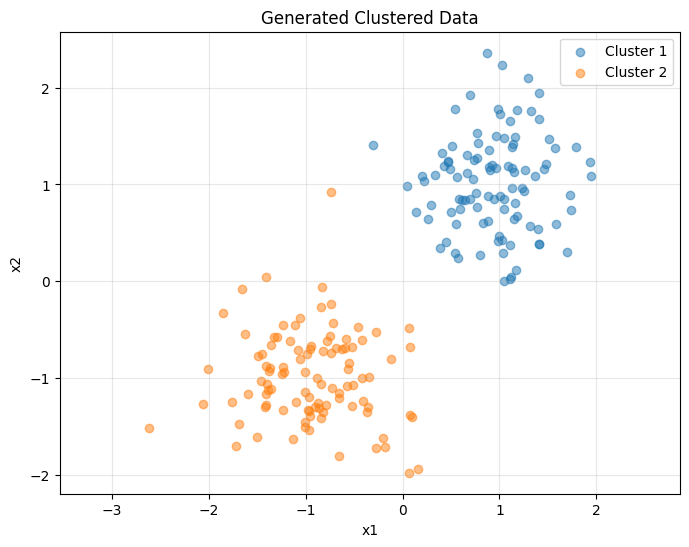

In [2]:
# Reproducibility
np.random.seed(42)

# Generate data
n_samples = 100

cluster1 = np.random.randn(n_samples, 2) * 0.5 + np.array([1, 1])
cluster2 = np.random.randn(n_samples, 2) * 0.5 + np.array([-1, -1])

X = np.vstack([cluster1, cluster2])

# Visualize the data
plt.figure(figsize=(8, 6))
plt.scatter(X[:n_samples, 0], X[:n_samples, 1], alpha=0.5, label="Cluster 1")
plt.scatter(X[n_samples:, 0], X[n_samples:, 1], alpha=0.5, label="Cluster 2")
plt.xlabel("x1")
plt.ylabel("x2")
plt.title("Generated Clustered Data")
plt.legend()
plt.grid(True, alpha=0.3)
plt.axis("equal")
plt.show()

## 3. Implement Unsupervised Hebbian Learning
Define a function to implement the basic Hebbian learning rule: $$\Delta w_i = \eta \cdot y \cdot x_i$$. Train a single neuron on the clustered data. Here, $w_i$ is the i-th weight, $\eta$ is the learning rate, $y$ is the neuron's output, and $x_i$ is the i-th input.

In [3]:
def hebbian_learning(X, n_inputs, learning_rate=0.01, epochs=30):
    weights = np.random.randn(n_inputs) * 0.1
    weight_history = [weights.copy()]

    for epoch in range(epochs):
        for x in X:
            # Linear activation
            y = np.dot(x, weights)
            # Hebbian update
            weights += learning_rate * y * x
        weight_history.append(weights.copy())
        
    return weights, np.array(weight_history)

# Train with Hebbian learning
hebb_weights, hebb_weight_history = hebbian_learning(X, n_inputs=2, learning_rate=0.001, epochs=30)

print(f"Final Hebbian Weights: {hebb_weights}")

Final Hebbian Weights: [-30206.17572184 -32135.84199693]


## 4. Visualize Weight Evolution and Divergence
Track the weight vector's evolution during the Hebbian learning process. Plot the trajectory of the weight vector on top of the data scatter plot. This will visually demonstrate how the weights align with the data's correlation and also show the problem of unbounded weight growth (divergence).

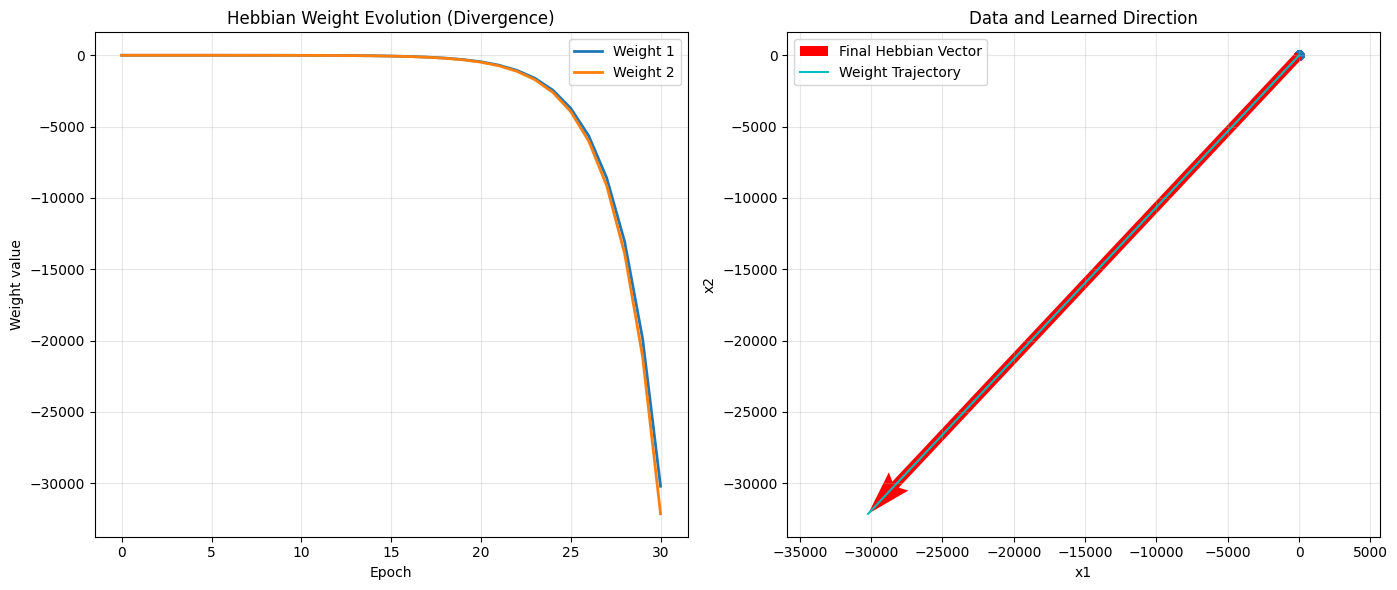

In [4]:
plt.figure(figsize=(14, 6))

# Plot 1: Weight evolution
plt.subplot(1, 2, 1)
plt.plot(hebb_weight_history[:, 0], label="Weight 1", linewidth=2)
plt.plot(hebb_weight_history[:, 1], label="Weight 2", linewidth=2)
plt.xlabel("Epoch")
plt.ylabel("Weight value")
plt.title("Hebbian Weight Evolution (Divergence)")
plt.legend()
plt.grid(True, alpha=0.3)

# Plot 2: Data + learned direction
plt.subplot(1, 2, 2)
plt.scatter(X[:, 0], X[:, 1], alpha=0.3)
origin = np.array([0, 0])
plt.quiver(*origin, hebb_weights[0], hebb_weights[1], angles="xy", scale_units="xy", scale=1, color="r", width=0.015, label="Final Hebbian Vector")
plt.plot(hebb_weight_history[:, 0], hebb_weight_history[:, 1], 'c-', label='Weight Trajectory')
plt.xlabel("x1")
plt.ylabel("x2")
plt.title("Data and Learned Direction")
plt.legend()
plt.grid(True, alpha=0.3)
plt.axis("equal")

plt.tight_layout()
plt.show()

## 5. Implement Oja's Rule (Normalized Hebbian Learning)
Define a function to implement Oja's rule, which introduces a normalization term to prevent weight divergence: $$\Delta w_i = \eta \cdot y \cdot (x_i - y \cdot w_i)$$. Train a new neuron using Oja's rule on the same dataset and visualize the weight vector's convergence to a unit length.

In [5]:
def oja_learning(X, n_inputs, learning_rate=0.001, epochs=30):
    weights = np.random.randn(n_inputs) * 0.1
    weight_history = [weights.copy()]
    norm_history = [np.linalg.norm(weights)]

    for epoch in range(epochs):
        for x in X:
            # Linear activation
            y = np.dot(x, weights)
            # Oja's update rule
            delta_w = learning_rate * y * (x - y * weights)
            weights += delta_w
        weight_history.append(weights.copy())
        norm_history.append(np.linalg.norm(weights))
        
    return weights, np.array(weight_history), np.array(norm_history)

# Train with Oja's rule
oja_weights, oja_weight_history, oja_norm_history = oja_learning(X, n_inputs=2, learning_rate=0.001, epochs=30)

print(f"Final Oja's Weights: {oja_weights}")
print(f"Final Oja's Weight Norm: {np.linalg.norm(oja_weights)}")

Final Oja's Weights: [0.6849518  0.72866847]
Final Oja's Weight Norm: 1.0000583516222


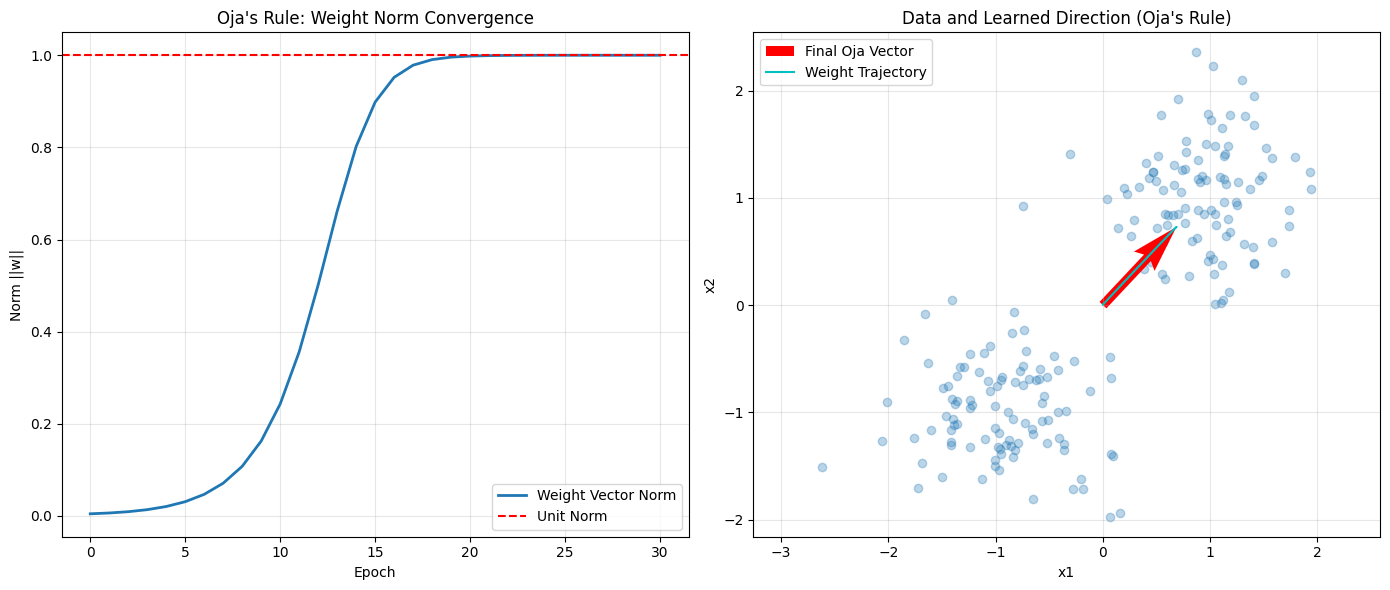

In [6]:
plt.figure(figsize=(14, 6))

# Plot 1: Weight norm evolution
plt.subplot(1, 2, 1)
plt.plot(oja_norm_history, label="Weight Vector Norm", linewidth=2)
plt.axhline(1, color='r', linestyle='--', label="Unit Norm")
plt.xlabel("Epoch")
plt.ylabel("Norm ||w||")
plt.title("Oja's Rule: Weight Norm Convergence")
plt.legend()
plt.grid(True, alpha=0.3)

# Plot 2: Data + learned direction
plt.subplot(1, 2, 2)
plt.scatter(X[:, 0], X[:, 1], alpha=0.3)
origin = np.array([0, 0])
plt.quiver(*origin, oja_weights[0], oja_weights[1], angles="xy", scale_units="xy", scale=1, color="r", width=0.015, label="Final Oja Vector")
plt.plot(oja_weight_history[:, 0], oja_weight_history[:, 1], 'c-', label='Weight Trajectory')
plt.xlabel("x1")
plt.ylabel("x2")
plt.title("Data and Learned Direction (Oja's Rule)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.axis("equal")

plt.tight_layout()
plt.show()

## 6. Demonstrate PCA Connection with Oja's Rule
Show that the weight vector learned by Oja's rule converges to the principal eigenvector of the input data's covariance matrix. Use NumPy to calculate the first principal component of the dataset and compare it with the final weight vector from Oja's rule.

Oja's learned weight vector: [0.6849518  0.72866847]
First Principal Component:   [0.68385612 0.72961689]
Dot product (alignment):     1.0000573033171887


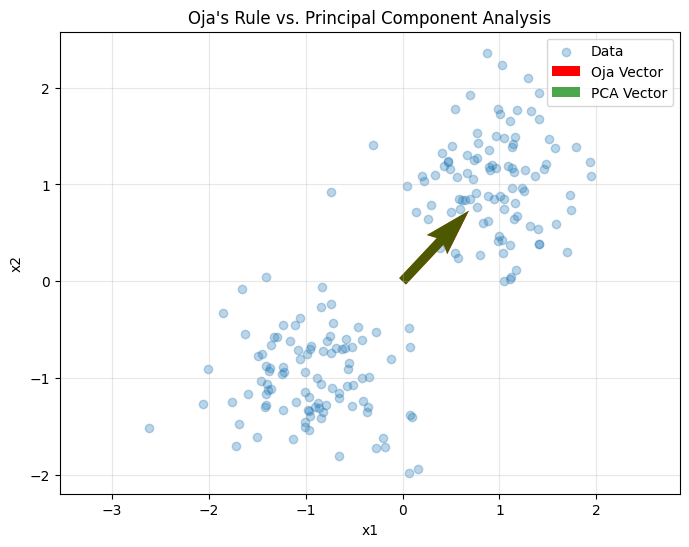

In [7]:
# Center the data
X_centered = X - np.mean(X, axis=0)

# Calculate the covariance matrix
cov_matrix = np.cov(X_centered, rowvar=False)

# Find eigenvalues and eigenvectors
eigenvalues, eigenvectors = np.linalg.eig(cov_matrix)

# The first principal component is the eigenvector with the largest eigenvalue
pca_vector = eigenvectors[:, np.argmax(eigenvalues)]

# Ensure the PCA vector and Oja vector point in the same general direction for comparison
if np.dot(pca_vector, oja_weights) < 0:
    pca_vector = -pca_vector

print(f"Oja's learned weight vector: {oja_weights}")
print(f"First Principal Component:   {pca_vector}")
print(f"Dot product (alignment):     {np.dot(oja_weights, pca_vector)}")

# Plot the results
plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], alpha=0.3, label="Data")
origin = np.array([0, 0])
plt.quiver(*origin, oja_weights[0], oja_weights[1], angles="xy", scale_units="xy", scale=1, color="r", width=0.015, label="Oja Vector")
plt.quiver(*origin, pca_vector[0], pca_vector[1], angles="xy", scale_units="xy", scale=1, color="g", width=0.015, alpha=0.7, label="PCA Vector")
plt.xlabel("x1")
plt.ylabel("x2")
plt.title("Oja's Rule vs. Principal Component Analysis")
plt.legend()
plt.grid(True, alpha=0.3)
plt.axis("equal")
plt.show()

## 7. Implement a Simple Associative Memory
Use a Hebbian-style rule to store a few simple patterns (e.g., small bitmap images) in a weight matrix. Implement a recall function that can retrieve a stored pattern from a noisy or incomplete version of it. This demonstrates the concept of content-addressable memory.

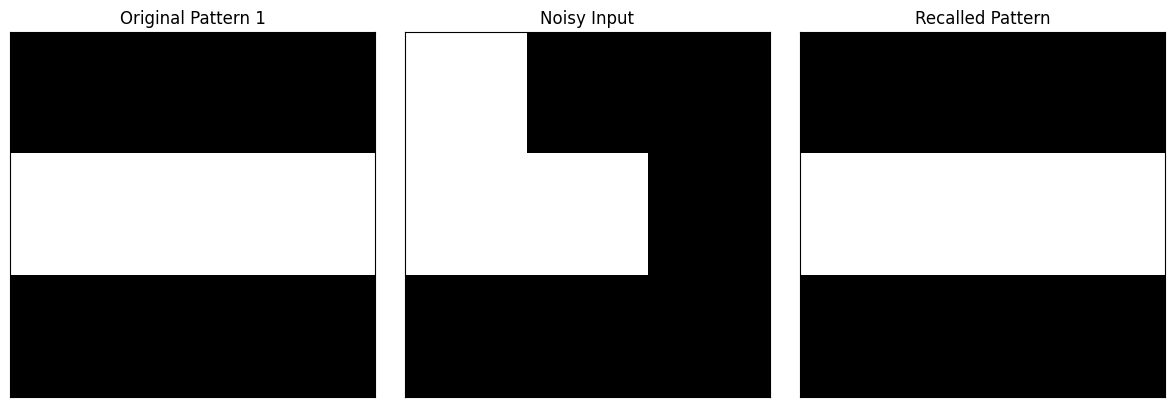

Recall successful: True


In [8]:
# Define patterns to store (using bipolar representation: +1 and -1)
pattern1 = np.array([1, 1, 1, -1, -1, -1, 1, 1, 1]) # A 'C' like shape
pattern2 = np.array([-1, 1, -1, -1, 1, -1, -1, 1, -1]) # A vertical line
patterns = [pattern1, pattern2]
n_neurons = len(pattern1)

# Store patterns using the Hebbian rule (outer product)
W = np.zeros((n_neurons, n_neurons))
for p in patterns:
    W += np.outer(p, p)
np.fill_diagonal(W, 0) # No self-connections

# Recall function
def recall(W, pattern, steps=5):
    recalled_pattern = pattern.copy()
    for _ in range(steps):
        # Update rule: s_i(t+1) = sign(sum_j(W_ij * s_j(t)))
        recalled_pattern = np.sign(np.dot(W, recalled_pattern))
        # Replace 0 with -1 if any (sign can be 0)
        recalled_pattern[recalled_pattern == 0] = -1
    return recalled_pattern

# Create a noisy version of pattern1
noisy_pattern1 = pattern1.copy()
noisy_pattern1[0] = -1
noisy_pattern1[5] = 1

# Recall the pattern from the noisy version
recalled = recall(W, noisy_pattern1)

# --- Visualization ---
def plot_pattern(pattern, title=""):
    plt.imshow(pattern.reshape(3, 3), cmap='binary', vmin=-1, vmax=1)
    plt.title(title)
    plt.xticks([])
    plt.yticks([])

plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1)
plot_pattern(pattern1, "Original Pattern 1")
plt.subplot(1, 3, 2)
plot_pattern(noisy_pattern1, "Noisy Input")
plt.subplot(1, 3, 3)
plot_pattern(recalled, "Recalled Pattern")
plt.tight_layout()
plt.show()

# Check if recall was successful
print(f"Recall successful: {np.array_equal(recalled, pattern1)}")